## [✔] COMPLETO

In [152]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Exercício:

## 01 – Usando o método np.random.normal(), gere valores de expressão gênica de um conjunto de 1.000 genes. Esse conjunto de ter valores up e downregulated.

In [13]:
array_expressao_quatorze = np.random.normal(size=1000)
array_expressao_quatorze = np.round(array_expressao_quatorze, 2)

## 02 – Usando o método np.random.randint(), gere valores para o número de genes diferencialmente expressos em um conjunto de 1.000 pacientes. Esse conjunto deve ter valores up e downregulated.

Instancie um objeto da classe DataFrame, com os dados gerados nos dois exercícios.

In [20]:
array_genes_quatorze = np.random.randint(1000, size=1000)

In [70]:
df_quatorze = pd.DataFrame(index= [f"Paciente {i}" for i in range(1, 1001)])

df_quatorze["Número de genes"] = array_genes_quatorze

df_quatorze["Expressão gênica"] = array_expressao_quatorze

df_quatorze

,Número de genes,Expressão gênica
Paciente 1,367,0.17
Paciente 2,266,0.91
Paciente 3,734,-0.39
Paciente 4,509,-0.17
Paciente 5,943,-0.66
...,...,...
Paciente 996,432,1.79
Paciente 997,148,0.57
Paciente 998,634,-0.22
Paciente 999,543,-0.00


## 03 – Categorize em grupos de 6 os dados contidos na DataFrame anterior, segundo critérios escolhidos por você. Explique os critérios.

In [50]:
df_quatorze.describe()

,Número de genes,Expressão gênica
count,1000.000000,1000.000000
mean,490.737000,0.036680
std,293.900291,0.984594
min,0.000000,-3.540000
25%,241.000000,-0.590000
50%,473.500000,0.020000
75%,753.000000,0.740000
max,996.000000,2.790000


R.: Aqui eu primeiro usei o método describe() do DataFrame para ter uma ideia geral dos valores e como descreve-los. Então decidi primeiro usar um condicional baseado no ponto 0 para definir a expressão gênica dos genes como Upregulated(+), Downregulated(-)ou Sem mudança(|). Apliquei também o mesmo conceito para o número de genes usando os quartis como base, onde o número de genes foi classificado entre valor mínimo, baixo, médio, alto e valor máximo.
<br>Por fim, também decidi fazer uma proporção Nº de Genes e Expressão para ter uma relação entre os dois valores que possa ser analisada. Para isso em uma nova coluna multipliquei os valores do Nº de genes pela expressão para obter a proporção relativa da expressão pelo número de genes. Nesta proporção, um maior pool de genes e mais expressos vai apresentar um grande valor proporcional positivo, enquanto poucos genes vão apresentar menor valor e expressão reduzida vai apresentar um valor negativo.
<br>O paciente 999 por exemplo, nesse conjunto de dados, apresenta um pool de número de genes consideravel (554) mas sem mudança de expressão (0), portando sua proporção relativa é 0, pois não contribui para a análise de expressão.

In [71]:
quartis_exp = [-3.54, -0.01, 0.01, 279]
rotulos_exp = ["-", "|", "+"]
df_quatorze["Regulation"] = pd.cut(df_quatorze["Expressão gênica"],
                                   bins=quartis_exp,
                                   labels=rotulos_exp,
                                   right=True)

quartis_genes = [0, 241, 473, 753, 996]
rotulos_genes = ["Baixo", "Médio", "Alto", "Máximo"]
df_quatorze["Classificação Nº de genes"] = pd.cut(df_quatorze["Número de genes"],
                                                  bins=quartis_genes,
                                                  labels=rotulos_genes,
                                                  right=True)

df_quatorze["Proporção genes/expressão"] = (df_quatorze["Número de genes"] * df_quatorze["Expressão gênica"]).round(3)

df_quatorze

,Número de genes,Expressão gênica,Regulation,Classificação Nº de genes,Proporção genes/expressão
Paciente 1,367,0.17,+,Médio,62.39
Paciente 2,266,0.91,+,Médio,242.06
Paciente 3,734,-0.39,-,Alto,-286.26
Paciente 4,509,-0.17,-,Alto,-86.53
Paciente 5,943,-0.66,-,Máximo,-622.38
...,...,...,...,...,...
Paciente 996,432,1.79,+,Médio,773.28
Paciente 997,148,0.57,+,Baixo,84.36
Paciente 998,634,-0.22,-,Alto,-139.48
Paciente 999,543,-0.00,|,Alto,-0.00


## 04 – Defina uma função em Python que receba uma pd.Series contendo uma variável quantitativa e retorne uma DataFrame contendo a tabela de frequência.

Obtenha a tabela de frequência das variáveis criadas nos exercícios 1 e 2.

In [95]:
def converteDataFrame(serie: pd.Series):
    df = pd.DataFrame(serie)
    return pd.DataFrame(df.value_counts(), columns=["Frequência"])

In [96]:
df_freq_numero = converteDataFrame(df_quatorze["Número de genes"])
df_freq_numero

,Frequência
Número de genes,
292,6
24,5
768,5
223,5
357,5
...,...
605,1
604,1
173,1


In [97]:
df_freq_exp = converteDataFrame(df_quatorze["Expressão gênica"])
df_freq_exp

,Frequência
Expressão gênica,
-0.29,10
0.00,9
-0.78,8
-0.24,8
0.41,8
...,...
-0.55,1
-0.37,1
-0.27,1


## 05 – Gere os gráficos de barras e linhas para as frequências em cada umas das variáveis.

<Axes: xlabel='Número de genes'>

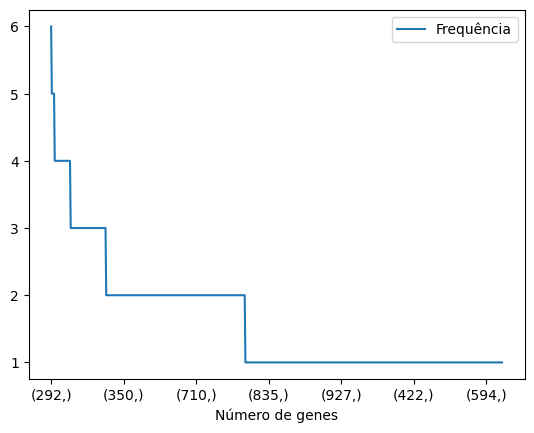

In [91]:
df_freq_numero.plot.line(y="Frequência")

### Expressão

<Axes: xlabel='Expressão gênica'>

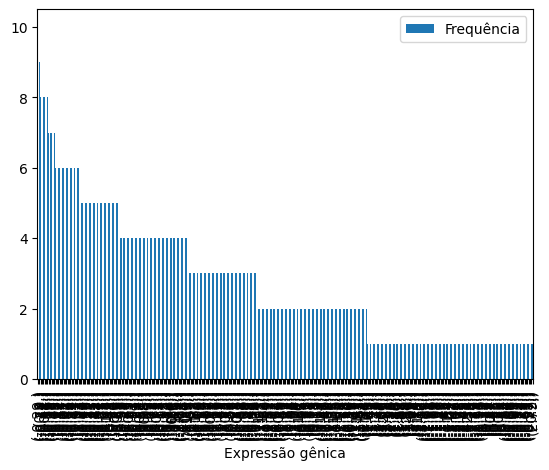

In [102]:
df_freq_exp.plot.bar(y="Frequência")

<Axes: xlabel='Expressão gênica'>

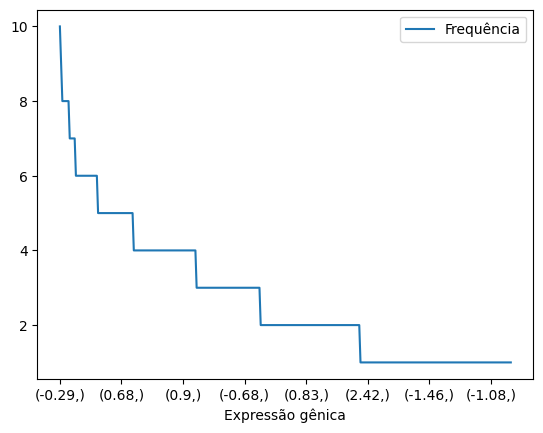

In [98]:
df_freq_exp.plot.line(y="Frequência")

### Número

<Axes: xlabel='Número de genes'>

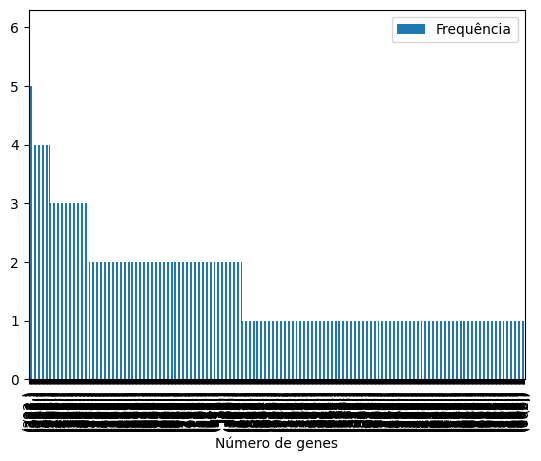

In [103]:
df_freq_numero.plot.bar(y="Frequência")

<Axes: xlabel='Número de genes'>

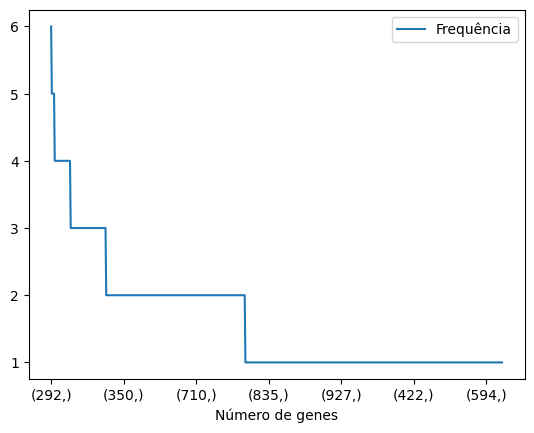

In [104]:
df_freq_numero.plot.line(y="Frequência")

## 06 – Gere os histogramas para as variáveis obtidas nos exercícios 1 e 2.

<Axes: ylabel='Frequency'>

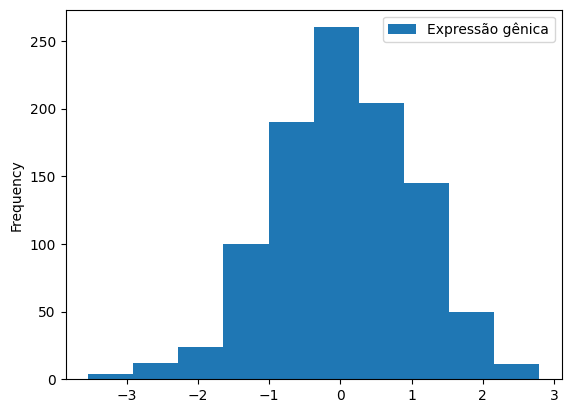

In [105]:
df_quatorze.plot.hist(y="Expressão gênica")

<Axes: ylabel='Frequency'>

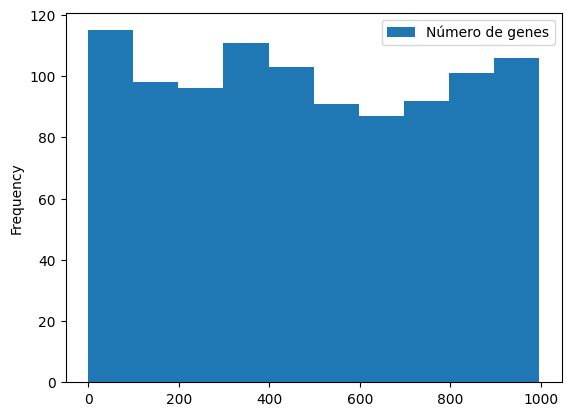

In [108]:
df_quatorze.plot.hist(y="Número de genes")

## 07 – Gere um gráfico de dispersão para as variáveis obtidas nos exercícios 1 e 2.

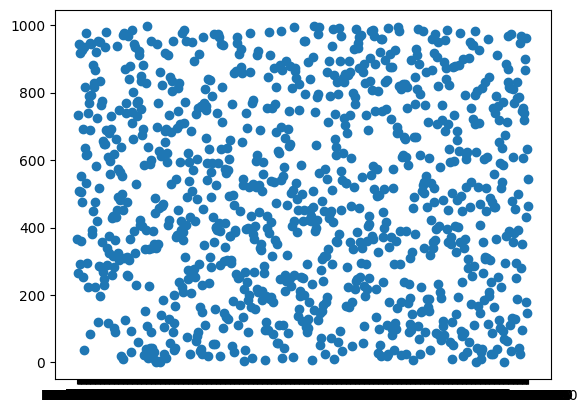

In [114]:
plt.scatter(df_quatorze.index, df_quatorze["Número de genes"])

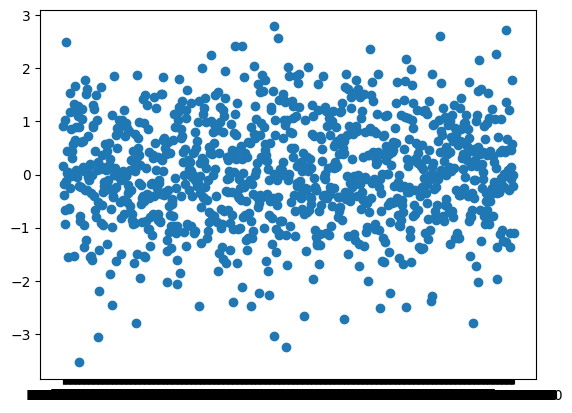

In [115]:
plt.scatter(df_quatorze.index, df_quatorze["Expressão gênica"])


## 08 – Gere o mesmo gráfico do exercício 06, porém, categorizado.

In [122]:
df_quatorze.head()

,Número de genes,Expressão gênica,Regulation,Classificação Nº de genes,Proporção genes/expressão
Paciente 1,367,0.17,+,Médio,62.39
Paciente 2,266,0.91,+,Médio,242.06
Paciente 3,734,-0.39,-,Alto,-286.26
Paciente 4,509,-0.17,-,Alto,-86.53
Paciente 5,943,-0.66,-,Máximo,-622.38


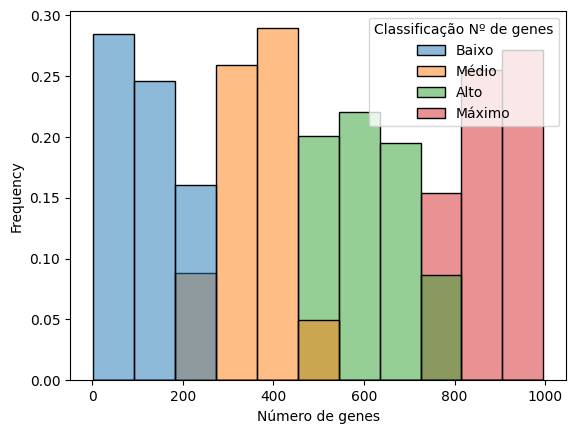

In [167]:
sns.histplot(data=df_quatorze, x="Número de genes",
             hue="Classificação Nº de genes",
             stat="frequency")
plt.show()

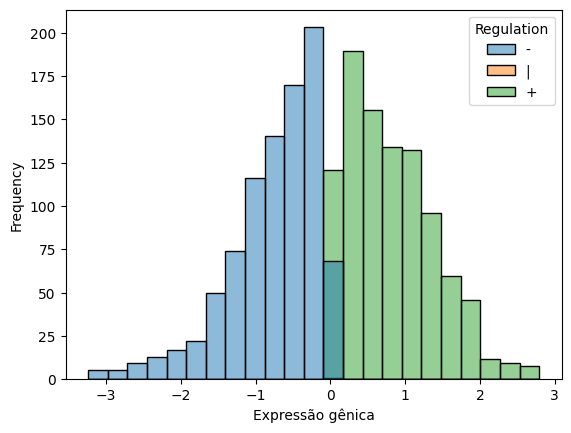

In [168]:
sns.histplot(data=df_quatorze, x="Expressão gênica",
             hue="Regulation",
             stat="frequency")
plt.show()

## 09 – Gere o mesmo gráfico do exercício 07, porém, categorizado.

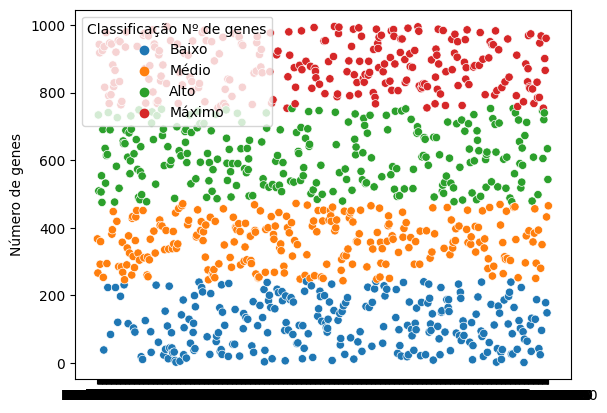

In [160]:
sns.scatterplot(data=df_quatorze, x=df_quatorze.index, y="Número de genes", hue="Classificação Nº de genes")
plt.show()

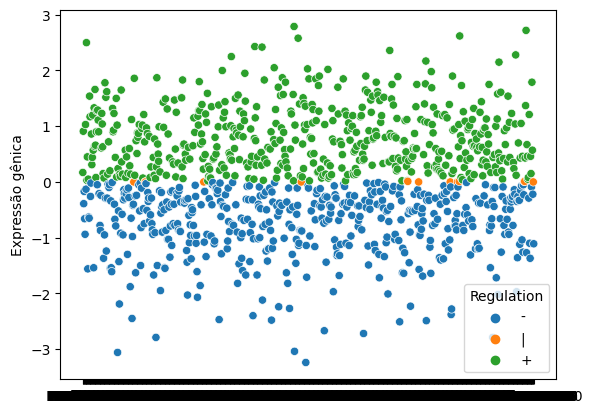

In [156]:
sns.scatterplot(data=df_quatorze, x=df_quatorze.index, y="Expressão gênica", hue="Regulation")
plt.show()

## 10 – Indique o tipo da variável:

- Discreta
- Contínua
- Ordinal
- Nominal

| Variável | Valor |
| :--- | :---: |
| # de células positivas| Discreta|
| % de células positivas| Contínua|
| Faixa de pH| Ordinal|
| Valor de pH| Contínua|
| mol/L| Contínua|
| UFC| Discreta|
| D.O.| Contínua|
| Grupo Sanguíneo| Nominal|
| Sorologia| Nominal|